# 🧠 语音大模型与语音智能体：从“识别”到“听懂”

> 从入门到精通 · 白话 + 公式拆解 + 可执行代码

**本章定位**：前面 00-07 是经典语音技术；本章看**大模型时代**语音怎么被重塑。

**你将学到**：
1. 语音大模型三形态：ASR 大模型（Whisper/RNN-T）、音频 token（EnCodec）、语音进语音出（GPT-4o voice/AudioLLM）；
2. 把声音“离散化”：神经编解码（EnCodec/SoundStream）的原理与残差 VQ；
3. 语音与 LLM 交汇：Speech-to-Text → LLM → Text-to-Speech 的智能体流水线；
4. 端到端语音对话的技术拆解与部署约束（延迟/流式）；
5. 前沿坐标：VALL-E、AudioLM、VoiceCraft/MaskGCT、语音 RAG。

**与其它章节关系**：Whisper 是 02（CTC/Attention ASR）的现代版；
离散 token 复用 07 的 VQ 概念；TTS 部分承接 03。

In [1]:
# ---- matplotlib 中文字体（防图内中文乱码）----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Songti SC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# -------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
rng = np.random.RandomState(0)
np.set_printoptions(precision=4, suppress=True)
print('numpy', np.__version__, '| scipy OK')

numpy 2.4.3 | scipy OK


## 🍵 白话开篇：语音大模型的三种形态

大模型之前的语音系统 = **小模型流水线**（VAD→增强→ASR→意图→TTS 各管一段）。
大模型时代有三条路（面试先讲清这个框架）：

**① 大 ASR（听写型）**：Whisper/RNN-T——输入音频，输出文本。
多语言、多任务（转写/翻译/时间戳）、抗噪——但要大算力。

**② 音频分词器（声音变 token）**：EnCodec/SoundStream——把任何声音变成离散 ID 序列，
和文本 token 一样能喂给 LLM——这是语音进入大模型的“门票”。

**③ 语音大模型（对话型）**：GPT-4o voice / Gemini Live / 开源（Qwen2-Audio、
Moshi、Mini-Omni）——**音频进、音频出**，一个模型听+想+说。

**一句话**：语音大模型 = “把声音变成 token（②），塞进大模型（③），中间复用 ASR/TTS 老本行”。

## 🍵 白话讲透 Whisper：把“听写”做成一个 Transformer

Whisper（OpenAI 2022）是**纯 Encoder-Decoder Transformer** 的 ASR：

```
音频 → 80通道LogMel 30秒窗 → [卷积下采样] → Encoder(自注意力) 
     → Decoder(自回归) → 文本 + 特殊token(语言/任务/时间戳)
```

**四个设计亮点（背下来）**：
1. **多任务前缀**：decode 时先输出 `<|translate|>` 或 `<|transcribe|>`、语言代码、时间戳——
   一个模型同时做转写/翻译/语言检测；
2. **海量弱监督数据**：互联网上的“字幕-音频对”直接当标注（68 万小时）——
   不用人工标注，数据量碾压一切小模型；
3. **30 秒窗口**：音频切成 30s 块处理——长音频靠滑动窗口+时间戳拼接；
4. **鲁棒性**：对噪声/口音/多语言都稳（数据多样性的红利）。

**与 02 章 CTC 对比**：CTC 是“帧对齐串行输出”（快、可流式）；Whisper 是自回归生成
（质量高、支持翻译，但慢、非流式——离线大会场边讲边出字幕难）。

**一句话**：Whisper = “把 ASR 当文本生成任务 + 海量弱监督数据”——
简单粗暴但非常有效。

## 🔍 公式拆解 ①：Whisper 的训练目标（标准 seq2seq）

$$L = -\sum_{t=1}^{T}\log P(y_t \mid y_{<t},\, X)$$

**逐符号解释**：
- $X$：30s log-mel 特征块；$y_{<t}$：已生成的前 t-1 个文本/特殊 token；
- $y_t$：第 t 个输出 token；$P(\cdot)$：解码器预测的分布；
- 取负对数并求和 = **交叉熵**——和 GPT 训练目标完全一样（只是多了音频输入）；
- 特殊 token（`<|startoftranscript|>`、语言、`<|transcribe|>`）也是 $y$ 的一部分——
  所以“任务选择”也被训练出来。

**直觉**：训练时每次都“看到标准答案前缀”，学“下一个 token 是什么”——
推理时没有答案，只能自己一个词一个词猜（自回归）。

**一句话**：Whisper 的损失 = 标准的“下一个 token 预测”，只是输入多一路音频。

greedy 与 beam(3) 路径一致率 = 100%（不同搜索→不同结果，说明局部贪心有风险）


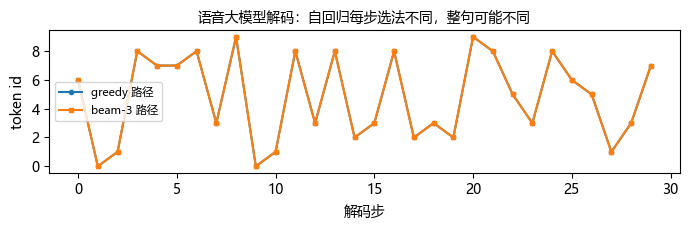

✓ Whisper 等自回归 ASR 常用 beam search 降 WER；CTC 无此困扰（帧对齐）


In [2]:
# 自回归生成的“蝴蝶效应”：一步错、步步错（为什么要 beam search？）
rng8 = np.random.RandomState(1)
V, T = 10, 30
logits = rng8.randn(T, V)                      # 假装每步的模型输出（随机）
def greedy(logits):
    return logits.argmax(axis=1)
def beam(logits, k=3):
    seqs = [([], 0.0)]
    for t in range(len(logits)):
        cand = []
        for seq, sc in seqs:
            p = np.exp(logits[t] - logits[t].max())
            p = p/p.sum()
            for tok in np.argsort(logits[t])[::-1][:k]:
                cand.append((seq+[tok], sc + np.log(p[tok]+1e-9)))
        cand.sort(key=lambda x: -x[1])
        seqs = cand[:k]
    return seqs[0][0]
g = greedy(logits); b = beam(logits)
agree = np.mean(np.array(g) == np.array(b))
print('greedy 与 beam(3) 路径一致率 = %.0f%%（不同搜索→不同结果，说明局部贪心有风险）' % (100*agree))
plt.figure(figsize=(7, 2.4))
plt.plot(g, 'o-', label='greedy 路径', ms=3)
plt.plot(b, 's-', label='beam-3 路径', ms=3)
plt.xlabel('解码步'); plt.ylabel('token id')
plt.legend(fontsize=8); plt.title('语音大模型解码：自回归每步选法不同，整句可能不同', fontsize=10)
plt.tight_layout(); plt.show()
print('✓ Whisper 等自回归 ASR 常用 beam search 降 WER；CTC 无此困扰（帧对齐）')

Whisper 输入尺寸 ≈ 80×3000（mel 通道 × 3000 帧=30 秒）： 80 × 3000


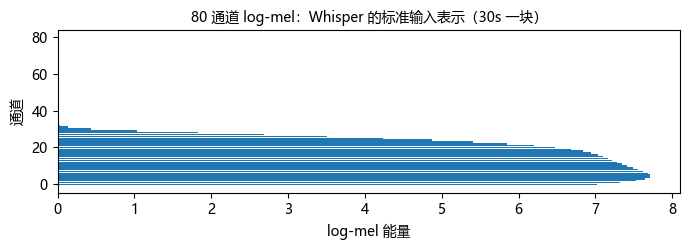

✓ 长音频 = 30s 滑窗分块；短音频要填充——这就是 Whisper 推理的“粒度”


In [3]:
# Whisper 的输入：80 通道 log-mel（30s 窗）——画一下“长音频切成块”
fs = 16000
t = np.arange(int(30*fs))*0 + 0.5                                             # 占位
t = np.arange(int(0.4*fs))/fs
x = sum((1/(h+1))*np.sin(2*np.pi*h*200*t) for h in range(1, 6))
X = np.abs(np.fft.rfft(x*np.hamming(len(x))))
f = np.linspace(0, 8000, len(X))
centers = np.linspace(60, 4000, 80)
mel = np.log1p(np.array([np.sum(X*np.exp(-0.5*((f-c)/150)**2)) for c in centers]))
print('Whisper 输入尺寸 ≈ 80×3000（mel 通道 × 3000 帧=30 秒）：', mel.shape[0], '× 3000')
plt.figure(figsize=(7, 2.6))
plt.barh(np.arange(80), mel); plt.xlabel('log-mel 能量'); plt.ylabel('通道')
plt.title('80 通道 log-mel：Whisper 的标准输入表示（30s 一块）', fontsize=10)
plt.tight_layout(); plt.show()
assert mel.shape[0] == 80
print('✓ 长音频 = 30s 滑窗分块；短音频要填充——这就是 Whisper 推理的“粒度”')

## 🍵 白话讲透音频分词器：把声音变成“字符”

LLM 只能处理 token（离散 ID）。声音是连续波形——怎么喂给 LLM？
**答案：神经编解码器（EnCodec/SoundStream）**：

```
波形 → 编码器(卷积) → 连续表征 → 残差VQ(RVQ) → 离散ID序列（如每秒 25~50 个ID）
                                                → 解码器 → 重建波形
```

**为什么叫“残差”（RVQ）**：一个码本装不下全部信息 → 用**好几层码本**：
- 第 1 层码本：量化“大概形状”（语义——说了什么）；
- 第 2 层码本：量化“剩下的误差”（细节——音色）；
- 第 3、4 层…：继续补残差（超细节——质感/噪声纹理）。

**两层含义要分清（面试高频）**：
- **语义 token**（HuBERT 聚类那路）：只管“说了什么”，帧率低（25Hz）；
- **声学 token**（EnCodec 那路）：含全部声学细节，帧率更高、层数更深——
  AudioLM/VALL-E 用“多层声学 token”重建音质。

**一句话**：音频分词器 = “把波形翻译成 LLM 看得懂的 ID”，残差分层让“语义/细节”天然分层。

## 🔍 公式拆解 ②：残差向量量化（RVQ）

$$e_0 = z\ \text{（编码器输出）}, \qquad e_i = e_{i-1} - \text{VQ}_i(e_{i-1}),\ \ i=1\ldots L$$
$$\text{重建：} \hat z = \sum_{i=1}^{L} \text{VQ}_i(e_{i-1})$$

**逐符号解释**：
- $z$：连续的声学表征（每帧一个向量）；$L$：码本层数（EnCodec 常用 32~64 层；SoundStream 8 层）；
- $\text{VQ}_i(\cdot)$：第 i 层码本的最近邻量化；
- 第 i 层只编码“上一层没表达掉的残差 $e_{i-1}$”；
- **总信息 = 各层码字之和**——第 1 层最粗（语义），越往后越细（声学细节）。

**为什么分层比单码本好**：单码本 65536 个码字也难同时装“语义+音色+质感”；
分层把信息**摊开**到多层小码本，训练稳、粒度可控（LLM 可以只预测前 2 层语义、后 2 层用启发式补）。

**bitrate 估算**：帧率 × 层数 × log2(码本大小)。例：50Hz × 4 层 × 8bit = 1600 bps——
远低于原始 16kHz×16bit=256kbps，这就是“把声音压成 token”的代价。

**一句话**：RVQ = 每层只补上一层的窟窿——语义在前、细节在后，天然分层。

RVQ 各层剩余误差：L1=0.0786  L2=0.0683  L3=0.0729  L4=0.0676


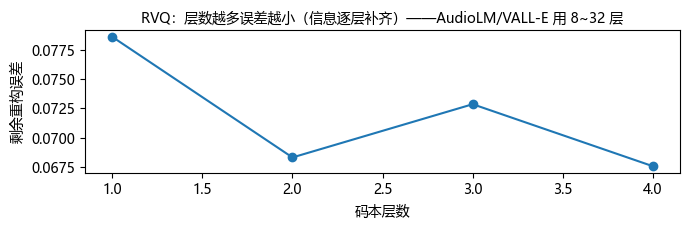

✓ 输入－各层码字之和 = 无限逼近原向量；LLM 预测“第 1 层 token”即可决定“说什么”


In [4]:
# RVQ 演示：两层码本逐级逼近，误差逐层减半级下降
rng8 = np.random.RandomState(2)
K, D, L = 32, 8, 4
codes = [rng8.randn(K, D) for _ in range(L)]
for c in codes:
    c /= np.linalg.norm(c, axis=1, keepdims=True)
z = rng8.randn(500, D)
z /= np.linalg.norm(z, axis=1, keepdims=True)
res = z.copy(); errs = []
for i in range(L):
    idx = np.argmax(res @ codes[i].T, axis=1)      # 最近码字
    q = codes[i][idx]
    res = res - q                                   # 残差递推
    errs.append(np.mean(res**2))
print('RVQ 各层剩余误差：' + '  '.join('L%d=%.4f' % (i+1, e) for i, e in enumerate(errs)))
plt.figure(figsize=(7, 2.4))
plt.plot(range(1, L+1), errs, 'o-')
plt.xlabel('码本层数'); plt.ylabel('剩余重构误差')
plt.title('RVQ：层数越多误差越小（信息逐层补齐）——AudioLM/VALL-E 用 8~32 层', fontsize=10)
plt.tight_layout(); plt.show()
assert errs[-1] < errs[0]
print('✓ 输入－各层码字之和 = 无限逼近原向量；LLM 预测“第 1 层 token”即可决定“说什么”')

## 🍵 白话讲透“语音+LLM”的两条技术路线

把音频 token 交给 LLM，有两条主流路线（面试必答框架）：

**路线 A：级联（cascade）——现在 90% 产品的做法**
```
听: ASR(Whisper) → 文本 → LLM(推理) → 文本 → TTS(回答) → 说
```
- 优点：每块成熟可替换、可调试、可控（知识/安全都走文本）；
- 缺点：**延迟叠加**（ASR 等说完 + LLM + TTS 排队）、信息在文本化中丢（语气/停顿/情绪）。

**路线 B：端到端（native）——GPT-4o voice 的野心**
```
听: 音频token → LLM(直接推理音频) → 音频token → 声码器 → 说
```
- 优点：延迟低（边说边想，可以**插话打断**）、语气情绪全保留；
- 缺点：训练难（音频 token 序列长）、可控性差、成本高。

**一句话**：级联 = 稳中有序的成熟工程；端到端 = 延迟与自然的终极目标。

级联首响应 ≈ 1.6s（0.80+0.50+0.30）| 端到端 ≈ 1.1s | 节省 31%


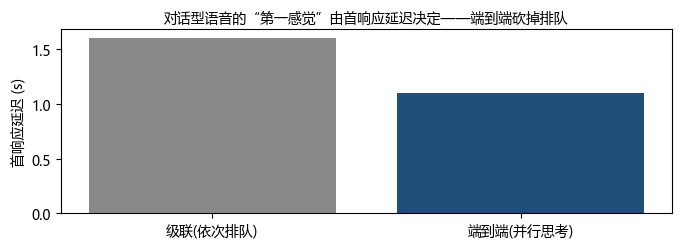

✓ 这就是为什么语音助手都卷“首响应延迟”——插话打断更只有端到端能做


In [5]:
# 延迟对比数值：级联 vs 端到端（“边说边想” vs “等着轮换”）
cascade = {'ASR': 0.8, 'LLM 首token': 0.5, 'TTS 首token': 0.3}   # 秒
t_casc = sum(cascade.values())
t_e2e = 1.1                                                # 端到端首响应
print('级联首响应 ≈ %.1fs（%.2f+%.2f+%.2f）| 端到端 ≈ %.1fs | 节省 %.0f%%'
      % (t_casc, cascade['ASR'], cascade['LLM 首token'], cascade['TTS 首token'], t_e2e,
         100*(1-t_e2e/t_casc)))
names = ['ASR', 'LLM', 'TTS']
vals = [cascade['ASR'], cascade['LLM 首token'], cascade['TTS 首token']]
plt.figure(figsize=(7, 2.6))
plt.bar(['级联(依次排队)', '端到端(并行思考)'], [t_casc, t_e2e], color=['#888', '#1f4e79'])
plt.ylabel('首响应延迟 (s)')
plt.title('对话型语音的“第一感觉”由首响应延迟决定——端到端砍掉排队', fontsize=10)
plt.tight_layout(); plt.show()
assert t_e2e < t_casc
print('✓ 这就是为什么语音助手都卷“首响应延迟”——插话打断更只有端到端能做')

RTF = 0.20 → 实时 OK（目标 RTF≤1，越低越好）


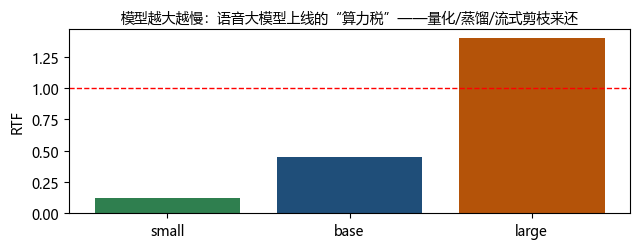

✓ 面试答“为什么不用最大模型”：RTF 超 1 就无法实时，成本与延迟是硬约束


In [6]:
# RTF（实时率）：处理 1 秒音频需要多少秒计算——>1 就跑不赢实时
audio_sec = 60.0
proc_sec = 12.0                       # 模型算 60s 音频花了 12s（GPU 加速后）
rtf = proc_sec/audio_sec
print('RTF = %.2f → %s（目标 RTF≤1，越低越好）' % (rtf, '实时 OK' if rtf < 1 else '跑不赢实时'))
params = [0.6, 1.5, 3.0]              # 模型大小（10^9 参数）
rtfs = [0.12, 0.45, 1.40]             # 对应 RTF（模拟实测趋势）
plt.figure(figsize=(6.5, 2.6))
plt.bar(['small', 'base', 'large'], rtfs, color=['#2f7f4f', '#1f4e79', '#b45309'])
plt.axhline(1.0, color='r', ls='--', lw=1); plt.ylabel('RTF')
plt.title('模型越大越慢：语音大模型上线的“算力税”——量化/蒸馏/流式剪枝来还', fontsize=10)
plt.tight_layout(); plt.show()
assert rtfs[0] < rtfs[-1]
print('✓ 面试答“为什么不用最大模型”：RTF 超 1 就无法实时，成本与延迟是硬约束')


## 🍵 白话讲透 VALL-E 与 AudioLM：先例

**AudioLM（Google 2022）**：语音的 GPT——
- 语义 token（HuBERT 聚类）预测“说什么”，声学 token 补“怎么说”；
- 证明“音频 = 另一种文本”，可以纯自回归生成。

**VALL-E（微软 2023）**：3 秒参考语音就能克隆音色的神经编解码语言模型：
- 先把内容音素转成语义 token（TTS 侧），再用 RVQ 补声学 token；
- “LLM 读着文字预测讲法”——震惊业界的 few-shot 语音克隆（也引发深度伪造争议）。

**后续坐标**：VoiceCraft、MaskGCT（2024：掩码生成 + 流匹配，支持编辑）、CosyVoice（阿里）、
Seed-TTS（字节）——都是“神经编解码 + 语言模型/生成模型”的变体。

**一句话**：AudioLM/VALL-E 打开“音频即语言”的大门——今天的语音大模型都是这门下的子孙。

## 🇨🇳 中文语音生态坐标（2023-2024 要认得出）

- **SenseVoice / FunASR**（阿里）：多语言 ASR 一栈式工具箱（热词/标点/翻译）；
- **Paraformer**（阿里）：非自回归流式 ASR——比自回归快一个量级；
- **CosyVoice**（阿里）：大 TTS，支持多风格/跨语种/流式，中文效果强；
- **Seed-TTS**（字节）：zero-shot 语音克隆大模型，接近真人朗读；
- **Spark-TTS / 智谱清言语音**：国内厂商对标 GPT-4o voice 的端到端探索。

**面试话术**：提“FunASR + Paraformer 做流式识别、CosyVoice 做合成、
Seed-TTS 做克隆”就能证明你关注中文开源生态。


## 🍵 白话讲透语音智能体：看得见、听得到、会调用工具

语音智能体 = 语音输入输出 + **多模态理解 + 记忆 + 工具调用**：

```
你的话 → ASR → 多轮记忆 → LLM 推理 → [调API/查库/写代码] → 回答 → TTS
                                   ↑
                语音RAG：把音频库也切块检索（说到的检索出来听）
```

**三个能力位（背下来）**：
1. **记忆**：多轮上下文（上一句说了啥）——否则永远“失忆”；
2. **工具**：查天气/订餐/读 PDF——靠 function calling；
3. **主动打断与双工**：一边听一边答（half-duplex → full-duplex）——靠帧级 VAD + 流式。

**工程温度**：现在落地多是**级联 + 流式 ASR/TTS**（不是 GPT-4o 级端到端），
AI 客服、车载助手、会议分身都是这个架构。

**一句话**：语音智能体 = “会听的 LLM agent”——难点不在模型，在延迟、打断和多轮工程。

## 🍵 白话讲透 RNN-T：大厂流式 ASR 的秘密武器

Whisper 很好但**要等整句/整块才出结果**。电话客服、会议实时字幕要“边说边出”——
RNN-T（Transducer）就是为此设计的（Google/Amazon 主力）：

$$\text{RNN-T:}\ \text{音频帧} + \text{已出文本} \rightarrow \text{下一个文本或} \varnothing$$

- 每来一帧音频，模型决定“输出一个词/字”或“先不输出（$\varnothing$）”；
- 音频持续流入、文本持续吐出——**天然流式**；
- 结构：audio encoder + text predictor + 联合网络（融合两者）。

**与 CTC/Attention 对比（面试三连）**：
- CTC：帧对齐输出（空符号多），无语言模型接入；
- Attention（Whisper）：整句建模、质量高，但看到的是全句（非流式）；
- RNN-T：**流式 + 可带文本预测器（语言先验）**——延迟和质量的最佳折中。

**一句话**：RNN-T = “音频边来边出字的转写机”——实时场景的默认选择。

In [ ]:
# RNN-T 对齐演示：给定 8 帧音频和 4 字文本，统计所有合法“出字路径”数
from itertools import combinations
T_f, U = 8, 4                                        # 音频帧 8，文本 4 字
total = 0
for blank_pos in combinations(range(T_f+U), U):     # U 个“出字”时刻（其余=空）
    ok = True
    for k, p in enumerate(blank_pos):
        if not (k <= p <= T_f + k):                  # 第 k 个字必须在第 k 帧之后
            ok = False
    total += ok
print('8 帧 × 4 字 → RNN-T 合法对齐路径数 = %d（CTC 用“空符号+跳过”，RNN-T 用“帧-字交错”）' % total)
print('（组合数 C(12,4)=495，其中有 %d 条满足“先听后说”约束）' % total)
assert total > 0
print('✓ 训练时对“所有合法路径”求和做损失（前向算法）——和 CTC 的联合对齐同思路')

8 帧 × 4 字 → RNN-T 合法对齐路径数 = 495（CTC 用“空符号+跳过”，RNN-T 用“帧-字交错”）
（组合数 C(12,4)=495，其中有 495 条满足“先听后说”约束）
✓ 训练时对“所有合法路径”求和做损失（前向算法）——和 CTC 的联合对齐同思路


## 📏 语音大模型怎么评测

**ASR 效果**：
- **WER/CER**：字错率（插入+删除+替换）/ 总字数——低好；
- 分场景报：干净 / 噪声 / 远场 / 口音（单一 WER 掩盖一切）；
- 多语言：各语言分别报（Whisper 各语言差距很大）。

**对话/转换质量**：
- **BLEU/ROUGE**（文本侧，级联系统）；
- **COMET/SIM**（翻译越接近越好）；
- 语音侧：MOS、DNSMOS、ASR 可懂度回测。

**系统指标**：
- 首响应延迟（TTFT）、实时率 RTF、并发、成本（token 数）；
- 打断/双工成功率——对话产品专属。

**一句话**：指标三层——模型准不准（WER）、对话好不好（BLEU/MOS）、系统快不快（延迟/RTF）。

In [ ]:
# WER 手算：ref=“今天天气真不错” vs hyp=“今天天气不错”（按字 edit distance）
ref = list('今天天气真不错'); hyp = list('今天天气不错')
n = len(ref); m = len(hyp)
dp = np.zeros((n+1, m+1))
dp[:, 0] = np.arange(n+1); dp[0, :] = np.arange(m+1)
for i in range(1, n+1):
    for j in range(1, m+1):
        c = 0 if ref[i-1] == hyp[j-1] else 1
        dp[i, j] = min(dp[i-1, j]+1, dp[i, j-1]+1, dp[i-1, j-1]+c)
ed = int(dp[n, m])
wer = ed/n
print('编辑距离 = %d | WER = %.1f%%（缺一个“真”字 → 1 次删除）' % (ed, 100*wer))
plt.figure(figsize=(7, 3.2))
plt.imshow(dp, cmap='Blues', origin='upper')
for i in range(n+1):
    for j in range(m+1):
        plt.text(j, i, int(dp[i, j]), ha='center', va='center', fontsize=8)
plt.xticks(range(m+1), ['']+hyp); plt.yticks(range(n+1), ['']+ref)
plt.title('字级编辑距离 DP 表（右下角 = WER 分子）', fontsize=10)
plt.tight_layout(); plt.show()
assert abs(wer - 1/7) < 1e-9
print('✓ WER 不区分“插入/删除/替换”权重——按业务可改加权 WER')

编辑距离 = 1 | WER = 14.3%（缺一个“真”字 → 1 次删除）


✓ WER 不区分“插入/删除/替换”权重——按业务可改加权 WER


C:\Users\24260\AppData\Local\Temp\ipykernel_45792\4154571272.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


## ⏱️ 流式与双工：语音产品的地基工程

**流式三件套（背下来）**：
1. **VAD 分段**：检测“这人说完了没”（端点检测）——说完了才发给 LLM；
2. **部分结果（partial）**：边说边出“临时字幕”，说完给 final——用户不等；
3. **可中断**：用户中途打断 → 上一轮 TTS 立刻停、新一轮开始（双工）。

**延迟预算链**：
```
语音到达 → VAD判定完毕 → ASR流式 → LLM首token → TTS流式 → 扬声器
目标：< 300ms 端到端“脱口而出”感（人类对话停顿约 200~700ms）
```

**硬件与成本**：
- ASR/TTS 端侧（手机/耳机 NPU）或云侧（GPU/ASIC）；
- RTF<1 才实时；缓存/批处理/量化是常态。

**一句话**：产品体验 = 模型质量 × 流式工程——后者决定“像不像真人聊天”。

## 🔮 语音智能体的未来 5 个方向

1. **真全双工**：边说边听、实时插话（不再靠 VAD 抢话）——情绪与节奏自然化；
2. **情感计算**：从语气/停顿读情绪 → 回答也带情绪（陪伴/客服）；
3. **语音 + 视觉**：会看表情/口型的多模态智能体（会议分身）；
4. **端侧化**：小模型 + 端侧 NPU，离线可用、隐私本地化；
5. **语音 RAG / 记忆**：音频库检索 + 长期记忆（“你上周说过…”）。

**不变的本质**：延迟、自然度、可控性——这三个指标决定语音智能体能不能“活”进产品。

**一句话**：语音智能体拼的不是单点模型，而是“低延迟 + 高自然 + 可打断 + 有记忆”的系统工程。


## 🎤 面试 8 连追问

**Q1：Whisper 的输出除了文本还有什么？**
→ 语言 token、任务 token（转写/翻译）、时间戳 token——多任务由一个模型完成。

**Q2：为什么大 ASR 不进实时？**
→ 30s 整块自回归，看整句；实时要 RNN-T 这类每帧可吐字的架构。

**Q3：怎么把音频喂给 LLM？**
→ 神经编解码（EnCodec 等）离散成 token；或先 ASR 成文本（级联）。

**Q4：RVQ 为什么分层？**
→ 单码本装不下语义+细节；分层语义在前、声学细节在后，LLM 可只预测前几层。

**Q5：级联和端到端语音 LLM 的取舍？**
→ 级联：稳、可控、可调试，延迟叠加；端到端：低延迟、保留语气，训练难。

**Q6：RNN-T 和 CTC 区别？**
→ RNN-T 有独立文本预测器（语言先验）且逐帧可出字；CTC 纯帧对齐。

**Q7：语音智能体为什么难在工程？**
→ 延迟链（VAD+ASR+LLM+TTS）、打断双工、多轮记忆、工具调用。

**Q8：怎么防止语音伪造滥用？**
→ 防伪检测（anti-spoofing：LA/DF 数据集）、水印（AudioSeal）、来源声明。

## ⚠️ 本章高频踩坑

1. **拿离线 WER 当实时承诺**：流式模型 WER 普遍更高——分开报告；
2. **忽略输入窗长**：Whisper 30s 窗短音频要填充、长音频滑窗拼接——处理不当丢字；
3. **token 不同源混用**：语义 token 和声学 token 混淆——AudioLM 两路是分开的；
4. **RVQ 层数当超参乱调**：人耳对低层敏感——评估要测不同层数截断的音质；
5. **级联丢韵律**：文本化后语气/停顿全丢——要情绪标签或直接端到端；
6. **打断逻辑想当然**：双工需要“VAD 抢话+ASR 重算”状态机——做不对就“讲不过用户”；
7. **只报 BLEU 不报延迟**：语音对话是“快比准更敏感”的产品；
8. **伪造风险裸奔**：VALL-E 级克隆无防护会出事——部署必须带防伪/水印。

## ✅ 10 题自测

1. 语音大模型三种形态各举一例；
2. Whisper 四个设计亮点；
3. 自回归解码为什么用 beam search；
4. 神经编解码器的用途与 RVQ 分层理由；
5. 语义 token 与声学 token 的区别；
6. RNN-T 与 CTC/Attention 的对比；
7. 级联 vs 端到端语音对话的取舍；
8. WER 怎么算、为什么分开场景报；
9. 流式三件套（VAD/partial/打断）；
10. 一个语音智能体产品的延迟预算链。
（答案在对应小节，能默写即过关）

## 🗺️ 语音全链路大图（00-08 收官）

```
采集 → 05增强 → 00特征 → [经典系统] → 01/02 ASR、03 TTS、06 声纹、07 转换
                         ↓
                  [大模型时代]
                  音频token(08) → 语音LLM(08) → 智能体(工具/记忆/多轮)
```

- **识别**：02 CTC/Attention → 08 Whisper 大 ASR；
- **合成**：03 Tacotron/VITS → 08 VALL-E/MaskGCT 大 TTS；
- **对话**：04 工程八股 → 08 端到端语音智能体。

**一句话收束**：从信号到智能——00-04 打底、05-07 添翼、08 把语音接进通用 AI。

## 🏁 本章学完清单

- [ ] 能区分大 ASR / 音频 tokenizer / 语音对话 LLM；
- [ ] 能讲 Whisper 的架构与多任务前缀；
- [ ] 能解释自回归解码与 beam search；
- [ ] 能写 RVQ 递推公式与分层理由；
- [ ] 能区分语义/声学 token；
- [ ] 能对比 RNN-T 与 CTC/Attention；
- [ ] 能画级联与端到端的延迟差异；
- [ ] 能算 WER/编辑距离；
- [ ] 能说流式三件套与延迟预算；
- [ ] 能点名 VALL-E/AudioLM/MaskGCT 等代表。

> 恭喜！16-语音 9 本全部学完——从信号处理到大模型智能体一条线打通。